In [66]:
from collections import defaultdict, Counter
from PIL import Image, ImageOps, ImageEnhance
from pathlib import Path
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

import os
import shutil
import pillow_heif
import matplotlib.pyplot as plt
import random
import cv2
import splitfolders
import torch
import torch.nn as nn
import torch.optim as optim
import time
import seaborn as sns
import numpy as np

In [2]:
dataset_path = os.path.expanduser('~/Desktop/WildSnap-Dataset-copy')

# 1. Exploratory Data Analysis

## Summarize Dataset

In [3]:
def summarize_dataset(path):    
    if not os.path.exists(path):
        print("Folder not found. Please check the folder name and try again.")
        return

    report = []
    total_images = 0
    
    for folder_name in sorted(os.listdir(path)):
        folder_full_path = os.path.join(path, folder_name)
        
        # Detect only directories
        if os.path.isdir(folder_full_path):
            # Count image files in the folder (only .png, .jpg, .jpeg)
            images = [f for f in os.listdir(folder_full_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            count = len(images)
            report.append((folder_name, count))
            total_images += count

    print("-" * 40)
    print(f"{'Animal':<25} | {'Image Count':<10}")
    print("-" * 40)
    
    for name, count in report:
        status = "✅ Ready" if count >= 20 else "⚠️ Too few"
        print(f"{name:<25} | {count:<10} {status}")
        
    print("-" * 40)
    print(f"Total: {len(report)} categories | {total_images} images")

In [4]:
summarize_dataset(dataset_path)

----------------------------------------
Animal                    | Image Count
----------------------------------------
African_Pygmy_Dormouse    | 4          ⚠️ Too few
Albino_Burmese_Python     | 15         ⚠️ Too few
Albino_Siamese_Crocodile  | 25         ✅ Ready
Ball_Python               | 31         ✅ Ready
Black-headed_Caique       | 22         ✅ Ready
Blue-and-gold_Macaw       | 47         ✅ Ready
Blue-tongued_Skink        | 16         ⚠️ Too few
Budapest_Pigeon           | 22         ✅ Ready
Budgerigar                | 1          ⚠️ Too few
Burmese_Python            | 21         ✅ Ready
Cages                     | 55         ✅ Ready
Cockatiel                 | 7          ⚠️ Too few
Cuviers_Dwarf_Caiman      | 5          ⚠️ Too few
Gouldian_Finch            | 25         ✅ Ready
Green-cheeked_Conure      | 23         ✅ Ready
Grey_Crowned_Crane        | 43         ✅ Ready
Grey_Parrot               | 26         ✅ Ready
Iguana                    | 30         ✅ Ready
Madagascar_Gia

## Corrupted Images

In [5]:
def find_broken_images(base_path):
    base_path = Path(base_path)
    broken = []

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                try:
                    Image.open(img_path).verify()
                except Exception:
                    broken.append(img_path)

    return broken


In [6]:
find_broken_images(dataset_path)

[PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Muscovy_Duck/.DS_Store')]

## Visual EDA

In [7]:
# Display random samples from random classes
def visual_eda(base_path, num_samples=5):
    base_path = Path(base_path).expanduser()

    # Randomly select 3 subdirectories (classes)
    subdirs = [d for d in base_path.iterdir() if d.is_dir() and not d.name.startswith('.')]
    
    if not subdirs:
        print("No subdirectories found in the specified path.")
        return

    selected_classes = random.sample(subdirs, min(3, len(subdirs)))
    
    # Create subplots to show images
    fig, axes = plt.subplots(len(selected_classes), num_samples, figsize=(15, 10))
    
    if len(selected_classes) == 1:
        axes = axes.reshape(1, -1)

    for i, class_path in enumerate(selected_classes):
        images = [img for img in class_path.iterdir() 
                  if img.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                  and not img.name.startswith('.')]
        
        if not images:
            print(f"No images found in folder: {class_path.name}")
            continue

        samples = random.sample(images, min(num_samples, len(images)))
        
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_path.name}", fontsize=10)
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

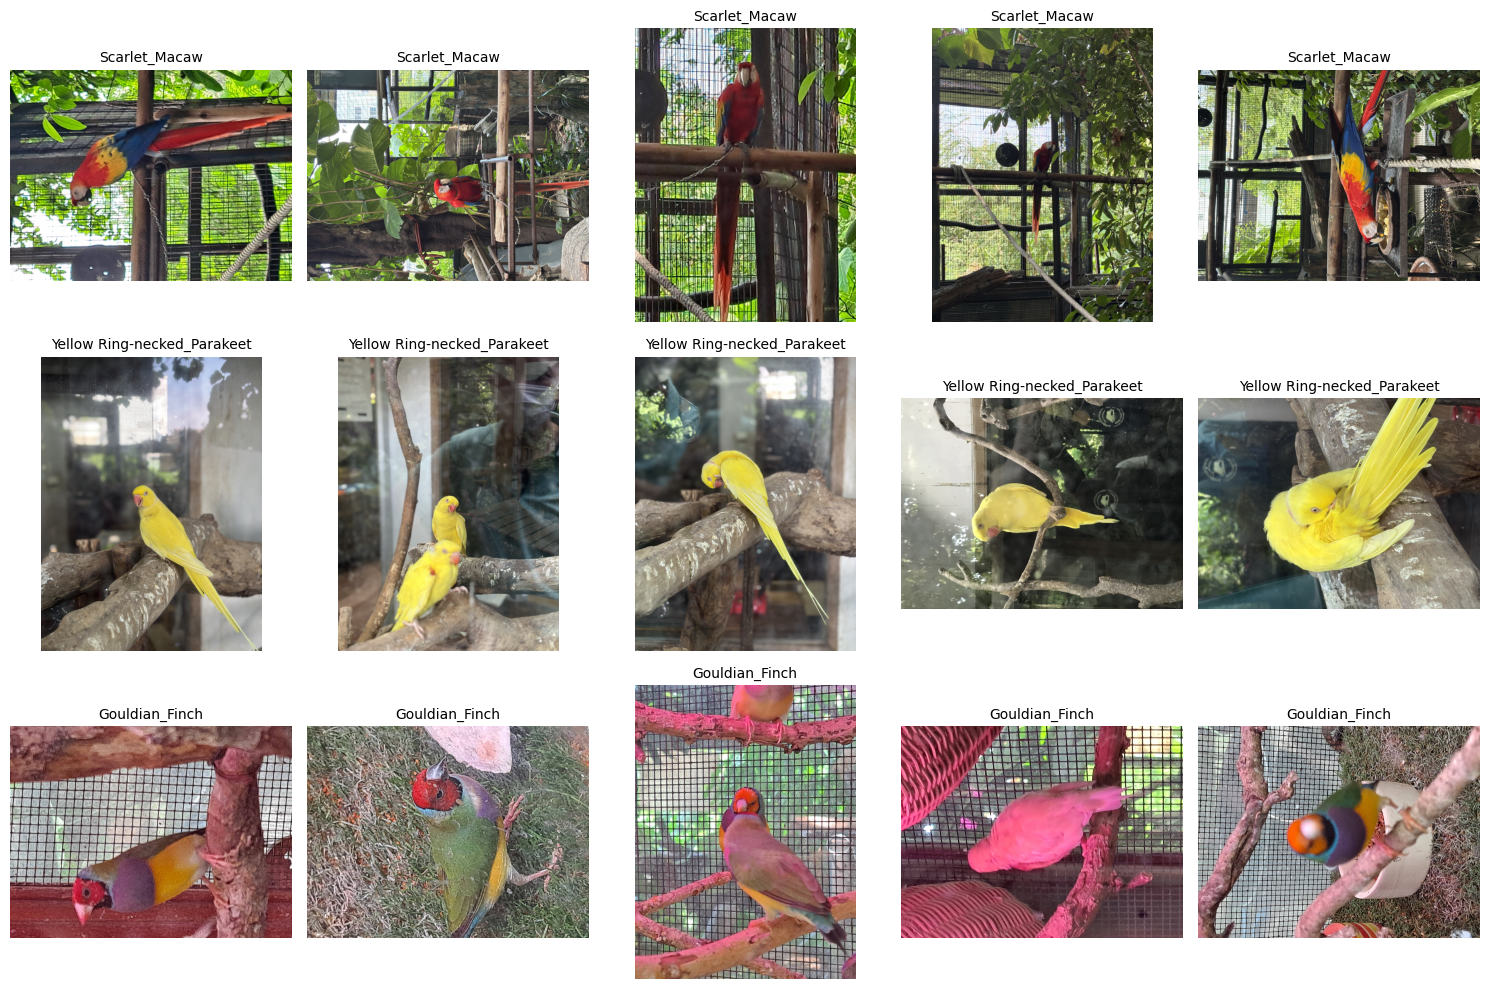

In [8]:
visual_eda(dataset_path)

## Image Size Summary

In [10]:
def image_size_summary(base_path):
    base_path = Path(base_path)
    size_counter = Counter()
    total_images = 0

    for img_path in base_path.rglob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(img_path) as img:
                size_counter[f"{img.width}x{img.height}"] += 1
                total_images += 1
        except Exception:
            continue

    # Print summary
    print("Image Size Summary:\n")
    for size, count in size_counter.most_common():
        print(f"{size} : {count} images")

    print(f"\nTotal image files counted: {total_images}")

    return size_counter

In [11]:
image_size_summary(dataset_path)

Image Size Summary:

4624x3468 : 357 images
1108x1477 : 160 images
4032x3024 : 126 images
3024x4032 : 53 images
5712x4284 : 42 images
1477x1108 : 5 images
4284x5712 : 4 images
1198x1562 : 1 images
1034x1568 : 1 images

Total image files counted: 749


Counter({'4624x3468': 357,
         '1108x1477': 160,
         '4032x3024': 126,
         '3024x4032': 53,
         '5712x4284': 42,
         '1477x1108': 5,
         '4284x5712': 4,
         '1198x1562': 1,
         '1034x1568': 1})

# 2. Data Filtering / Selection

## Quantity Filtering

In [14]:
dataset_path_obj = Path(dataset_path).expanduser()
target_path = Path('~/Desktop/WildSnap-Train-30plus').expanduser()

In [15]:
# Select only classes with more than 30 images
def filter_and_prepare_dataset(src, dest, min_limit=30):
    if not dest.exists():
        dest.mkdir(parents=True)
        print(f"📁 สร้างโฟลเดอร์ใหม่สำหรับ Experiment: {dest}")

    print(f"🔍 เริ่มคัดกรองสัตว์ที่มีรูปภาพ >= {min_limit} รูป...")
    print("-" * 50)
    
    selected_classes = 0
    total_images_copied = 0

    # วนลูปดูทุกโฟลเดอร์สัตว์ในต้นทาง
    for folder in sorted(src.iterdir()):
        # ข้ามไฟล์ระบบของ Mac (.DS_Store) และไฟล์อื่นๆ ที่ไม่ใช่โฟลเดอร์
        if folder.is_dir() and not folder.name.startswith('.'):
            # นับเฉพาะไฟล์รูปภาพ
            images = [f for f in folder.iterdir() 
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                      and not f.name.startswith('.')]
            
            count = len(images)
            
            if count >= min_limit:
                # ถ้าผ่านเกณฑ์ ให้ Copy ไปยังโฟลเดอร์ใหม่
                dest_folder = dest / folder.name
                
                # ถ้าโฟลเดอร์ปลายทางมีอยู่แล้ว ให้ลบทิ้งแล้วสร้างใหม่ (เพื่อให้ข้อมูลไม่อัปเดตซ้ำซ้อน)
                if dest_folder.exists():
                    shutil.rmtree(dest_folder)
                
                shutil.copytree(folder, dest_folder)
                
                print(f"✅ {folder.name:<25} | จำนวน: {count:>3} รูป [คัดลอกแล้ว]")
                selected_classes += 1
                total_images_copied += count
            else:
                # ถ้าไม่ผ่านเกณฑ์ ให้แสดงว่าข้ามไป
                print(f"❌ {folder.name:<25} | จำนวน: {count:>3} รูป [ไม่ถึงเกณฑ์ - ข้าม]")

    print("-" * 50)
    print(f"✨ สรุปผล: เลือกมาได้ทั้งหมด {selected_classes} ชนิด")
    print(f"📸 รวมจำนวนรูปภาพที่พร้อมเทรน: {total_images_copied} รูป")
    print(f"📍 ข้อมูลอยู่ที่: {dest}")

In [16]:
filter_and_prepare_dataset(dataset_path_obj, target_path, min_limit=30)

🔍 เริ่มคัดกรองสัตว์ที่มีรูปภาพ >= 30 รูป...
--------------------------------------------------
❌ African_Pygmy_Dormouse    | จำนวน:   4 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Albino_Burmese_Python     | จำนวน:  15 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Albino_Siamese_Crocodile  | จำนวน:  25 รูป [ไม่ถึงเกณฑ์ - ข้าม]
✅ Ball_Python               | จำนวน:  31 รูป [คัดลอกแล้ว]
❌ Black-headed_Caique       | จำนวน:  22 รูป [ไม่ถึงเกณฑ์ - ข้าม]
✅ Blue-and-gold_Macaw       | จำนวน:  47 รูป [คัดลอกแล้ว]
❌ Blue-tongued_Skink        | จำนวน:  16 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Budapest_Pigeon           | จำนวน:  22 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Budgerigar                | จำนวน:   1 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Burmese_Python            | จำนวน:  21 รูป [ไม่ถึงเกณฑ์ - ข้าม]
✅ Cages                     | จำนวน:  55 รูป [คัดลอกแล้ว]
❌ Cockatiel                 | จำนวน:   7 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Cuviers_Dwarf_Caiman      | จำนวน:   5 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Gouldian_Finch            | จำนวน:  25 รูป [ไม่ถึงเกณฑ์ - ข้าม]
❌ Gre

In [18]:
summarize_dataset(target_path)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Ball_Python               | 31         ✅ Ready
Blue-and-gold_Macaw       | 47         ✅ Ready
Cages                     | 55         ✅ Ready
Grey_Crowned_Crane        | 43         ✅ Ready
Iguana                    | 30         ✅ Ready
Meerkat                   | 43         ✅ Ready
Muscovy_Duck              | 36         ✅ Ready
Scarlet_Macaw             | 36         ✅ Ready
Sulphur-crested_Cockatoo  | 52         ✅ Ready
----------------------------------------
Total: 9 categories | 373 images


# 3. Data Preprocessing

## Resize Image to 512 x 512

In [19]:
input_base_path = Path(target_path).expanduser()
output_base_path = Path('~/Desktop/WildSnap-Final-512').expanduser()

In [21]:
def resize_and_pad(img_path, output_path, size=512):
    """ฟังก์ชันขยาย/ลดขนาดภาพให้เป็น 512x512 โดยเติมขอบดำ"""
    try:
        with Image.open(img_path) as img:
            # แปลงเป็น RGB (ป้องกันปัญหาไฟล์ PNG มี Alpha channel หรือไฟล์ CMYK)
            img = img.convert('RGB')
            
            # คำนวณสัดส่วนเพื่อ Resize ให้ด้านที่ยาวที่สุดเท่ากับ 512
            img.thumbnail((size, size), Image.Resampling.LANCZOS)
            
            # สร้างพื้นหลังสีดำขนาด 512x512
            new_img = Image.new("RGB", (size, size), (0, 0, 0))
            
            # วางรูปลงตรงกลางพื้นหลัง
            left = (size - img.width) // 2
            top = (size - img.height) // 2
            new_img.paste(img, (left, top))
            
            # บันทึกไฟล์
            new_img.save(output_path, "JPEG", quality=95)
    except Exception as e:
        print(f"❌ ไม่สามารถจัดการไฟล์ {img_path.name} ได้: {e}")

In [22]:
# 2. เริ่มต้นกระบวนการ Batch Processing
print("🎨 กำหนดขนาดภาพเป็น 512x512 พร้อมเติมขอบดำ...")

if not output_base_path.exists():
    output_base_path.mkdir(parents=True)

for class_folder in sorted(input_base_path.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        # สร้างโฟลเดอร์ชื่อสัตว์ในปลายทาง
        output_class_dir = output_base_path / class_folder.name
        output_class_dir.mkdir(exist_ok=True)
        
        print(f"Processing: {class_folder.name}...")
        
        # จัดการทุกรูปในโฟลเดอร์นั้น
        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                output_file_path = output_class_dir / f"{img_file.stem}.jpg"
                resize_and_pad(img_file, output_file_path, size=512)

print(f"\n✨ เสร็จสมบูรณ์! รูปภาพทั้งหมดอยู่ที่: {output_base_path}")

🎨 กำหนดขนาดภาพเป็น 512x512 พร้อมเติมขอบดำ...
Processing: Ball_Python...
Processing: Blue-and-gold_Macaw...
Processing: Cages...
Processing: Grey_Crowned_Crane...
Processing: Iguana...
Processing: Meerkat...
Processing: Muscovy_Duck...
Processing: Scarlet_Macaw...
Processing: Sulphur-crested_Cockatoo...

✨ เสร็จสมบูรณ์! รูปภาพทั้งหมดอยู่ที่: /Users/smileymacz/Desktop/WildSnap-Final-512


In [23]:
image_size_summary(output_base_path)

Image Size Summary:

512x512 : 373 images

Total image files counted: 373


Counter({'512x512': 373})

# 4. Data Augmentation

In [25]:
input_base_path = Path(output_base_path).expanduser()
target_count = 55  # จำนวนรูปที่ต้องการในแต่ละ Class

In [26]:
def augment_image(img):
    """ฟังก์ชันสุ่มการปรับแต่งรูปภาพ"""
    # สุ่มกลับด้านซ้าย-ขวา
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    
    # สุ่มหมุนภาพ (-15 ถึง 15 องศา)
    angle = random.randint(-15, 15)
    img = img.rotate(angle, fillcolor=(0,0,0)) # หมุนแล้วเติมขอบดำ
    
    # สุ่มปรับความสว่าง (0.8 ถึง 1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    
    return img

In [27]:
print(f"🚀 เริ่มการ Augmentation เพื่อให้ทุก Class มี {target_count} รูป...")

for class_folder in sorted(input_base_path.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        # ดึงรายชื่อรูปที่มีอยู่แล้ว
        images = [f for f in class_folder.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        current_count = len(images)
        
        if current_count < target_count:
            num_to_add = target_count - current_count
            print(f"➕ {class_folder.name}: มี {current_count} รูป กำลังเพิ่มอีก {num_to_add} รูป...")
            
            for i in range(num_to_add):
                # สุ่มเลือกรูปต้นฉบับมา 1 รูปเพื่อเอามาปั่นใหม่
                source_img_path = random.choice(images)
                with Image.open(source_img_path) as img:
                    augmented_img = augment_image(img)
                    
                    # บันทึกรูปใหม่โดยตั้งชื่อไม่ให้ซ้ำเดิม
                    new_name = f"aug_{i}_{source_img_path.name}"
                    augmented_img.save(class_folder / new_name, "JPEG", quality=95)
        else:
            print(f"✅ {class_folder.name}: มีรูปเพียงพอแล้ว ({current_count} รูป)")

print(f"\n✨ เสร็จสิ้น! ตอนนี้ทุก Class ใน {input_base_path} มีอย่างน้อย {target_count} รูปแล้ว")

🚀 เริ่มการ Augmentation เพื่อให้ทุก Class มี 55 รูป...
➕ Ball_Python: มี 31 รูป กำลังเพิ่มอีก 24 รูป...
➕ Blue-and-gold_Macaw: มี 47 รูป กำลังเพิ่มอีก 8 รูป...
✅ Cages: มีรูปเพียงพอแล้ว (55 รูป)
➕ Grey_Crowned_Crane: มี 43 รูป กำลังเพิ่มอีก 12 รูป...
➕ Iguana: มี 30 รูป กำลังเพิ่มอีก 25 รูป...
➕ Meerkat: มี 43 รูป กำลังเพิ่มอีก 12 รูป...
➕ Muscovy_Duck: มี 36 รูป กำลังเพิ่มอีก 19 รูป...
➕ Scarlet_Macaw: มี 36 รูป กำลังเพิ่มอีก 19 รูป...
➕ Sulphur-crested_Cockatoo: มี 52 รูป กำลังเพิ่มอีก 3 รูป...

✨ เสร็จสิ้น! ตอนนี้ทุก Class ใน /Users/smileymacz/Desktop/WildSnap-Final-512 มีอย่างน้อย 55 รูปแล้ว


In [28]:
summarize_dataset(input_base_path)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Ball_Python               | 55         ✅ Ready
Blue-and-gold_Macaw       | 55         ✅ Ready
Cages                     | 55         ✅ Ready
Grey_Crowned_Crane        | 55         ✅ Ready
Iguana                    | 55         ✅ Ready
Meerkat                   | 55         ✅ Ready
Muscovy_Duck              | 55         ✅ Ready
Scarlet_Macaw             | 55         ✅ Ready
Sulphur-crested_Cockatoo  | 55         ✅ Ready
----------------------------------------
Total: 9 categories | 495 images


# 5. Data Splitting

In [31]:
input_folder = Path('~/Desktop/WildSnap-Final-512').expanduser()
output_folder = Path('~/Desktop/WildSnap-Split-Data').expanduser()

In [34]:
def split_dataset(input_folder, output_folder):
    """ฟังก์ชันแบ่งข้อมูลเป็น Train/Val/Test"""
    if not output_folder.exists():
        output_folder.mkdir(parents=True)
    
    print("🔀 กำลังแบ่งข้อมูลเป็น Train/Val/Test (80/10/10)...")
    
    splitfolders.ratio(input_folder, output=output_folder, 
                       seed=1337, ratio=(.8, .1, .1), 
                       group_prefix=None, move=False)
    
    print("✅ แบ่งข้อมูล Train/Val/Test เรียบร้อยแล้ว!")

In [35]:
split_dataset(input_folder, output_folder)

🔀 กำลังแบ่งข้อมูลเป็น Train/Val/Test (80/10/10)...
✅ แบ่งข้อมูล Train/Val/Test เรียบร้อยแล้ว!


# 6. Data Loader

## Tensor Conversion & Normalization

In [47]:
# ค่ามาตรฐานของ ImageNet (ห้ามเปลี่ยนค่าเหล่านี้หากใช้ Pre-trained Model)
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

In [48]:
def define_normalization_transforms():
    """ฟังก์ชันกำหนดการแปรรูปข้อมูลด้วย Normalization"""
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((224, 224)),   # ปรับขนาดให้เหมาะกับ B0
            transforms.ToTensor(),           # <--- ต้องอยู่ตรงนี้! (แปลงเป็นเลข 0.0-1.0 และสลับแกน)
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ทำต่อจาก Tensor
        ]),
        'val': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),           # ต้องมีทั้งใน Train และ Val
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    print("✅ กำหนดค่า Normalization เรียบร้อยแล้ว")
    return data_transforms

In [49]:
data_transforms = define_normalization_transforms()
data_transforms

✅ กำหนดค่า Normalization เรียบร้อยแล้ว


{'train': Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 'val': Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 )}

In [50]:
# Path ของโฟลเดอร์ที่คุณแบ่ง Train/Val/Test ไว้แล้ว
data_dir = Path('~/Desktop/WildSnap-Split-Data').expanduser()

In [51]:
# 1. สร้าง Dataset โดยใส่ transforms (ที่มี Normalization) เข้าไป
image_datasets = {
    x: datasets.ImageFolder(data_dir / x, data_transforms[x])
    for x in ['train', 'val']
}

# 2. สร้าง DataLoader (สายพานลำเลียงข้อมูล)
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=True)
    for x in ['train', 'val']
}

In [53]:
# ตรวจสอบขนาดข้อมูล
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"📊 สรุปข้อมูลที่ทำ Normalization แล้ว:")
print(f"- จำนวน Class: {len(class_names)} ชนิด")
print(f"- รูปภาพสำหรับเทรน: {dataset_sizes['train']} รูป")
print(f"- รูปภาพสำหรับตรวจสอบ: {dataset_sizes['val']} รูป")

📊 สรุปข้อมูลที่ทำ Normalization แล้ว:
- จำนวน Class: 9 ชนิด
- รูปภาพสำหรับเทรน: 396 รูป
- รูปภาพสำหรับตรวจสอบ: 45 รูป


# 7. Define Model

In [55]:
# 1. เลือก Device (สำคัญสำหรับคนใช้ Mac)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 กำลังใช้ Device: {device}")

# 2. โหลด EfficientNet-B0 แบบที่เรียนรู้มาแล้ว (Pre-trained)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 3. ปรับเปลี่ยนส่วนหัว (Classifier) ให้เท่ากับจำนวนสัตว์ของคุณ
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# ส่งโมเดลไปที่ GPU/CPU
model = model.to(device)

# 4. กำหนดตัววัดความผิดพลาด (Loss) และตัวปรับจูน (Optimizer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ นิยามโมเดลเสร็จแล้ว พร้อมจำแนกสัตว์ {len(class_names)} ชนิด")

🚀 กำลังใช้ Device: mps
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/smileymacz/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


✅ นิยามโมเดลเสร็จแล้ว พร้อมจำแนกสัตว์ 9 ชนิด


# 8. Start Training

In [60]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    # เก็บประวัติความแม่นยำเพื่อไปวาดกราฟ
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # วนลูปดึงข้อมูลจาก DataLoader
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward Pass (ให้ AI ทาย)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward Pass (ปรับจูนเฉพาะตอนเทรน)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.cpu().float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # บันทึกประวัติ
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

    time_elapsed = time.time() - since
    print(f'✨ เทรนเสร็จสิ้นใน {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

In [61]:
# เริ่มรันการเทรนจริง (ลองเริ่มที่ 10-15 รอบก่อนครับ)
trained_model, train_history = train_model(model, criterion, optimizer, num_epochs=15)

Epoch 1/15
----------
train Loss: 0.1955 Acc: 0.9495
val Loss: 0.2738 Acc: 0.9333
Epoch 2/15
----------
train Loss: 0.1242 Acc: 0.9646
val Loss: 0.0078 Acc: 1.0000
Epoch 3/15
----------
train Loss: 0.1365 Acc: 0.9545
val Loss: 0.0413 Acc: 0.9778
Epoch 4/15
----------
train Loss: 0.1380 Acc: 0.9571
val Loss: 0.0788 Acc: 0.9778
Epoch 5/15
----------
train Loss: 0.1006 Acc: 0.9672
val Loss: 0.3407 Acc: 0.9556
Epoch 6/15
----------
train Loss: 0.0887 Acc: 0.9697
val Loss: 0.4727 Acc: 0.9778
Epoch 7/15
----------
train Loss: 0.0596 Acc: 0.9874
val Loss: 0.1440 Acc: 0.9556
Epoch 8/15
----------
train Loss: 0.0658 Acc: 0.9798
val Loss: 0.0460 Acc: 0.9778
Epoch 9/15
----------
train Loss: 0.0340 Acc: 0.9924
val Loss: 0.0054 Acc: 1.0000
Epoch 10/15
----------
train Loss: 0.0273 Acc: 0.9949
val Loss: 0.1061 Acc: 0.9778
Epoch 11/15
----------
train Loss: 0.0205 Acc: 0.9924
val Loss: 0.0014 Acc: 1.0000
Epoch 12/15
----------
train Loss: 0.0265 Acc: 0.9975
val Loss: 0.0063 Acc: 1.0000
Epoch 13/15
-

# 9. Result Testing

## Learning Curves Result

In [62]:
def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # กราฟ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # กราฟ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

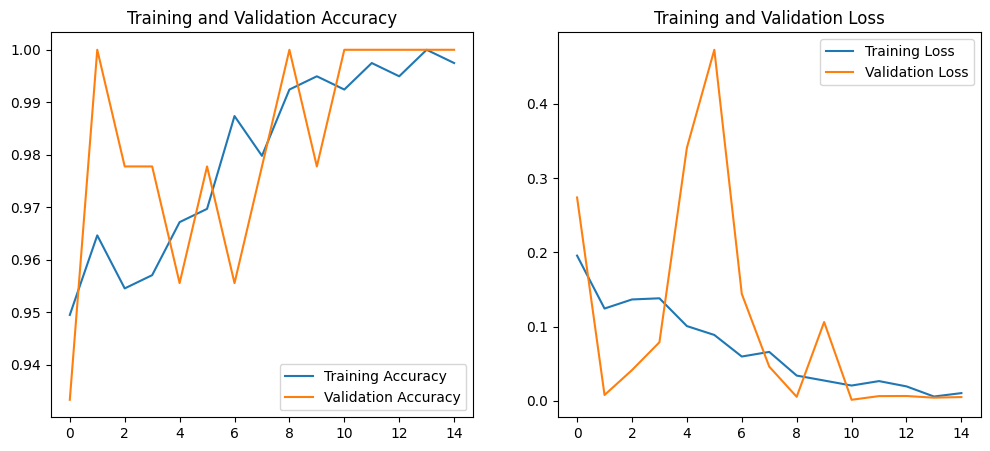

In [63]:
plot_history(train_history)

## Confusion Matrix

In [67]:
def show_confusion_matrix(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

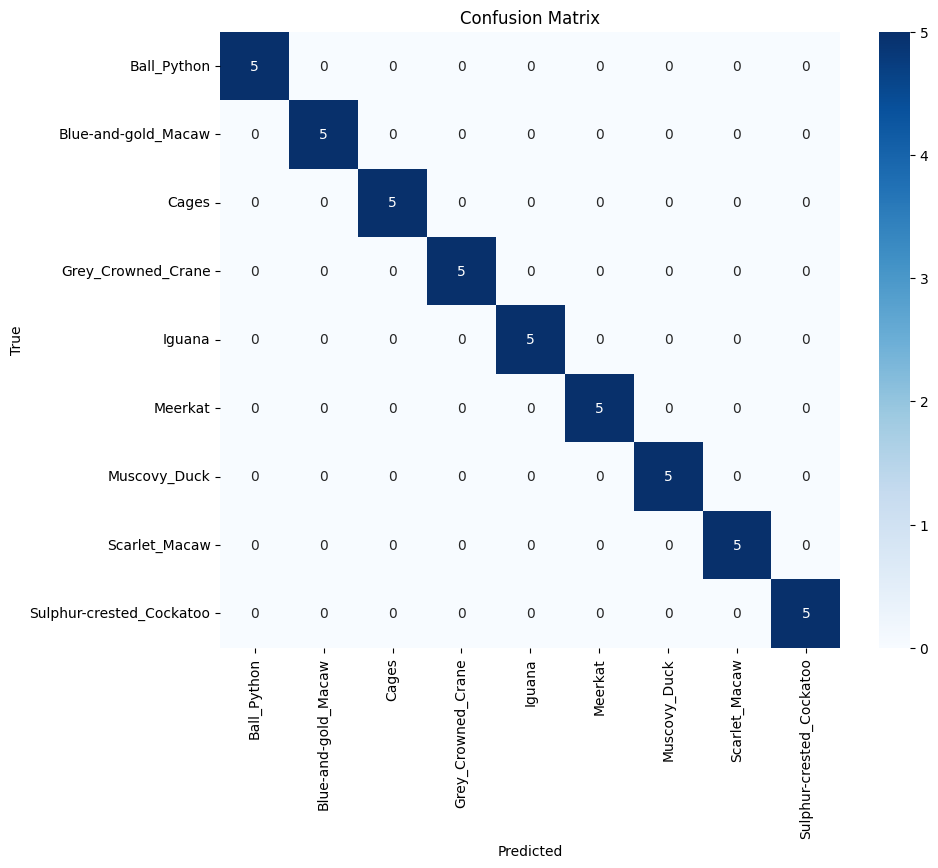

In [68]:
show_confusion_matrix(trained_model, dataloaders['val'])

## Test Model

In [70]:
# สร้าง Dataset สำหรับ Test
test_dataset = datasets.ImageFolder(data_dir / 'test', data_transforms['val'])

# สร้าง DataLoader สำหรับ Test
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"📋 จำนวนรูปภาพในข้อสอบสุดท้าย (Test Set): {len(test_dataset)} รูป")

📋 จำนวนรูปภาพในข้อสอบสุดท้าย (Test Set): 54 รูป


In [71]:
def evaluate_test_set(model, dataloader):
    model.eval()
    running_corrects = 0
    
    print("📝 กำลังเริ่มทำข้อสอบสุดท้าย (Testing)...")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
            
    test_acc = running_corrects.cpu().float() / len(dataloader.dataset)
    print(f"\n🎯 ความแม่นยำบน Test Set (ข้อมูลที่ไม่เคยเห็นเลย): {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_acc

In [72]:
final_test_acc = evaluate_test_set(trained_model, test_dataloader)

📝 กำลังเริ่มทำข้อสอบสุดท้าย (Testing)...

🎯 ความแม่นยำบน Test Set (ข้อมูลที่ไม่เคยเห็นเลย): 0.9815 (98.15%)


In [80]:
def evaluate_test_set_internet(model, image_path):
    # เตรียมรูปภาพ
    img = Image.open(image_path).convert('RGB')
    # ต้องใช้ transform เดียวกับตอน Val (Resize 224 + Normalize)
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, pred = torch.max(prob, 0)
    
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred]} ({conf*100:.2f}%)")
    plt.axis('off')
    plt.show()

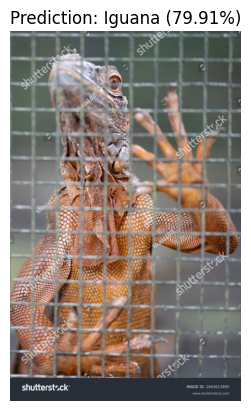

In [81]:
test_image = Path("~/Downloads/iguna01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

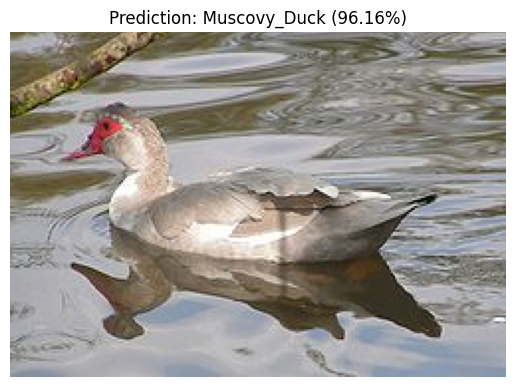

In [82]:
test_image = Path("~/Downloads/duck01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

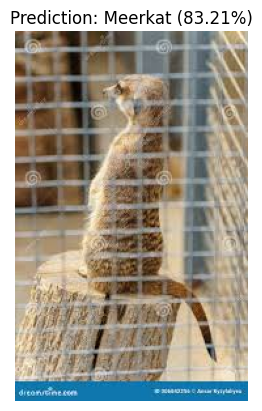

In [84]:
test_image = Path("~/Downloads/meercat01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

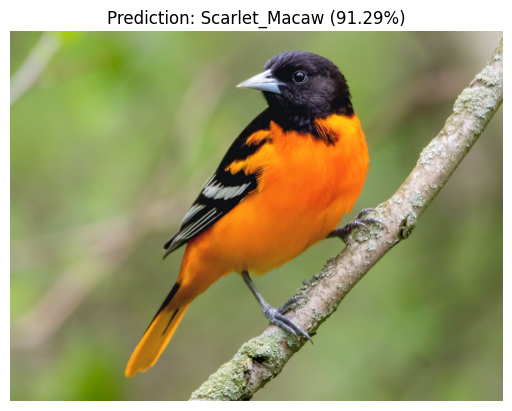

In [85]:
test_image = Path("~/Downloads/unknow-bird01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

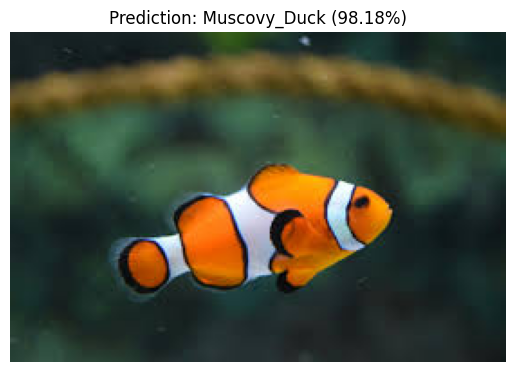

In [87]:
test_image = Path("~/Downloads/fish01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)